# Étape 3 — Modèle Finetuné

Ce notebook constitue le **Checkpoint 3** du projet Telco Customer Churn.
Il part du modèle baseline (Logistic Regression) et améliore la performance via :

1. **Feature engineering** — regroupement de modalités, indicateur familial
2. **Hyperparamètres** — GridSearchCV sur la Logistic Regression
3. **Calibration** — CalibratedClassifierCV (sigmoid)
4. **Choix de seuil** — optimisation coût/bénéfice métier
5. **Interprétabilité** — permutation importance
6. **Rapport comparatif** — baseline vs finetuné
7. **Scoring final** — CSV customerID / proba_churn / label_pred


## 1. Imports et chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, FunctionTransformer, StandardScaler
)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay, brier_score_loss, log_loss
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

# Reproductibilité
RANDOM_STATE = 42

# Création des dossiers de sortie
Path('../models').mkdir(exist_ok=True)
Path('../outputs').mkdir(exist_ok=True)
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

url = './../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url, sep=',', skipinitialspace=True)
print(f'Dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes')


Dataset : 7043 lignes x 21 colonnes


## 2. Feature engineering

Trois transformations motivées par l'EDA :

- **`PaymentMethod_grouped`** : les paiements automatiques (Bank transfer, Credit card) ont un taux de churn beaucoup plus faible que `Electronic check` et `Mailed check`. Regrouper réduit le bruit.
- **`Contract_grouped`** : `One year` et `Two year` ont des comportements très proches (churn faible). Les distinguer de `Month-to-month` est suffisant.
- **`has_family`** : les clients avec `Partner` ou `Dependents` churnent moins. Un indicateur binaire capture cet effet sans surcharger le modèle.


In [2]:
df['PaymentMethod_grouped'] = df['PaymentMethod'].replace({
    'Bank transfer (automatic)': 'Automatic',
    'Credit card (automatic)':   'Automatic'
})

df['Contract_grouped'] = df['Contract'].replace({
    'One year': 'Long term',
    'Two year': 'Long term'
})

df['has_family'] = (
    (df['Partner'] == 'Yes') | (df['Dependents'] == 'Yes')
).astype(int)

print('Nouvelles features créées :')
print('  PaymentMethod_grouped :', df['PaymentMethod_grouped'].value_counts().to_dict())
print('  Contract_grouped      :', df['Contract_grouped'].value_counts().to_dict())
print('  has_family            :', df['has_family'].value_counts().to_dict())


Nouvelles features créées :
  PaymentMethod_grouped : {'Automatic': 3066, 'Electronic check': 2365, 'Mailed check': 1612}
  Contract_grouped      : {'Month-to-month': 3875, 'Long term': 3168}
  has_family            : {1: 3763, 0: 3280}


## 3. Split train / test / validation

Même protocole que le baseline (random_state=42, stratify=Churn) pour garantir une comparaison équitable.


In [3]:
df_without_val, df_val = train_test_split(
    df, test_size=0.10, random_state=RANDOM_STATE, stratify=df['Churn']
)
df_train, df_test = train_test_split(
    df_without_val, test_size=0.20, random_state=RANDOM_STATE,
    stratify=df_without_val['Churn']
)

le = LabelEncoder()

features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'OnlineSecurity', 'InternetService', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'PaperlessBilling',
    'SeniorCitizen', 'has_family',
    'PaymentMethod_grouped', 'Contract_grouped'
]

X_train = df_train[features].copy()
X_test  = df_test[features].copy()
X_val   = df_val[features].copy()

y_train = le.fit_transform(df_train['Churn'].values)
y_test  = le.transform(df_test['Churn'].values)
y_val   = le.transform(df_val['Churn'].values)

print(f'Train : {len(X_train)} | Test : {len(X_test)} | Val : {len(X_val)}')
print(f'Taux churn — train : {y_train.mean():.2%} | test : {y_test.mean():.2%}')


Train : 5070 | Test : 1268 | Val : 705
Taux churn — train : 26.53% | test : 26.58%


## 4. Pipeline de prétraitement

Même architecture que le baseline : `ColumnTransformer` avec :
- imputation de `TotalCharges` (tenure × MonthlyCharges) + `StandardScaler` pour les numériques
- `OneHotEncoder` pour les catégorielles

Toutes les transformations apprennent **uniquement sur le train** — aucun leakage.


In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'has_family']
cat_cols = [
    'InternetService', 'PaymentMethod_grouped', 'Contract_grouped',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'PaperlessBilling'
]

def fill_total_charge(X):
    """
    Impute TotalCharges manquant par tenure * MonthlyCharges.
    Appelé uniquement sur le train via FunctionTransformer dans la pipeline.
    """
    X = X.copy()
    mask = X['TotalCharges'].isna()
    X.loc[mask, 'TotalCharges'] = X.loc[mask, 'tenure'] * X.loc[mask, 'MonthlyCharges']
    return X

num_pipe = make_pipeline(
    FunctionTransformer(fill_total_charge, validate=False, feature_names_out='one-to-one'),
    StandardScaler()
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)
preprocessor.set_output(transform='pandas')
print('Preprocessor défini.')


Preprocessor défini.


## 5. Baseline de référence

On recharge les métriques du baseline (Logistic Regression sans feature engineering ni calibration) pour avoir un point de comparaison objectif.


In [6]:
def precision_at_k(y_true, y_proba, k=10):
    """Proportion de vrais churners parmi les k% de clients les plus risqués."""
    n = int(len(y_true) * k / 100)
    top_idx = np.argsort(y_proba)[::-1][:n]
    return float(y_true[top_idx].mean())


def evaluate(name, model, X, y):
    """Calcule toutes les métriques pour un modèle donné."""
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'model':         name,
        'roc_auc':       round(roc_auc_score(y, y_proba), 4),
        'precision':     round(precision_score(y, y_pred, zero_division=0), 4),
        'recall':        round(recall_score(y, y_pred, zero_division=0), 4),
        'f1_score':      round(f1_score(y, y_pred, zero_division=0), 4),
        'precision@10%': round(precision_at_k(y, y_proba, k=10), 4),
        'brier_score':   round(brier_score_loss(y, y_proba), 4)
    }


# Baseline : Logistic Regression sans feature engineering
features_baseline = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
    'PaymentMethod', 'OnlineSecurity', 'InternetService', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'PaperlessBilling',
    'Dependents', 'Partner', 'SeniorCitizen'
]
num_cols_bl = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'TotalCharges']
cat_cols_bl = [
    'InternetService', 'PaymentMethod', 'Contract', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'PaperlessBilling',
    'Dependents', 'Partner'
]

preprocessor_bl = ColumnTransformer(transformers=[
    ('num', make_pipeline(
        FunctionTransformer(fill_total_charge, validate=False, feature_names_out='one-to-one'),
        StandardScaler()), num_cols_bl),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_bl),
])

baseline_pipe = make_pipeline(
    preprocessor_bl,
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
)
baseline_pipe.fit(df_train[features_baseline], y_train)

metrics_baseline = evaluate('Baseline (LR)', baseline_pipe, df_test[features_baseline], y_test)
print('Métriques baseline :')
for k, v in metrics_baseline.items():
    print(f'  {k:20s}: {v}')


Métriques baseline :
  model               : Baseline (LR)
  roc_auc             : 0.8461
  precision           : 0.5102
  recall              : 0.819
  f1_score            : 0.6287
  precision@10%       : 0.754
  brier_score         : 0.1681


## 6. Optimisation des hyperparamètres — GridSearchCV

On optimise la Logistic Regression sur le jeu finetuné (avec feature engineering). Paramètres explorés : `C` (régularisation) et `solver`. Scoring : `roc_auc`, CV=5.


In [7]:
pipe_lr = make_pipeline(
    preprocessor,
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
)

param_grid = {
    'logisticregression__C':      [0.01, 0.1, 1, 10, 100],
    'logisticregression__solver': ['liblinear', 'lbfgs'],
    'logisticregression__penalty':['l2']
}

grid_search = GridSearchCV(
    pipe_lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('Meilleurs paramètres :', grid_search.best_params_)
print('Meilleur score CV    :', round(grid_search.best_score_, 4))

best_lr = grid_search.best_estimator_
metrics_tuned = evaluate('LR finetuné (sans calibration)', best_lr, X_test, y_test)
print('\nMétriques LR finetuné :')
for k, v in metrics_tuned.items():
    print(f'  {k:30s}: {v}')


Meilleurs paramètres : {'logisticregression__C': 10, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Meilleur score CV    : 0.8407

Métriques LR finetuné :
  model                         : LR finetuné (sans calibration)
  roc_auc                       : 0.8443
  precision                     : 0.5162
  recall                        : 0.8042
  f1_score                      : 0.6288
  precision@10%                 : 0.754
  brier_score                   : 0.1676


c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 7. Calibration des probabilités

La Logistic Regression avec `class_weight='balanced'` peut produire des probabilités mal calibrées (décalées vers les extrêmes). On applique une calibration sigmoid (Platt scaling) via `CalibratedClassifierCV`.

Un **Brier score** plus faible et une courbe de calibration plus proche de la diagonale indiquent de meilleures probabilités — essentielles pour le scoring métier.


In [8]:
calibrated_pipe = make_pipeline(
    preprocessor,
    CalibratedClassifierCV(
        estimator=LogisticRegression(
            C=grid_search.best_params_['logisticregression__C'],
            solver=grid_search.best_params_['logisticregression__solver'],
            penalty='l2',
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        method='sigmoid',
        cv=5
    )
)
calibrated_pipe.fit(X_train, y_train)

y_proba_baseline   = baseline_pipe.predict_proba(df_test[features_baseline])[:, 1]
y_proba_finetuned  = calibrated_pipe.predict_proba(X_test)[:, 1]

print(f'Brier score — baseline  : {brier_score_loss(y_test, y_proba_baseline):.4f}')
print(f'Brier score — finetuné  : {brier_score_loss(y_test, y_proba_finetuned):.4f}')
print(f'Log loss   — baseline   : {log_loss(y_test, y_proba_baseline):.4f}')
print(f'Log loss   — finetuné   : {log_loss(y_test, y_proba_finetuned):.4f}')


Brier score — baseline  : 0.1681
Brier score — finetuné  : 0.1360
Log loss   — baseline   : 0.4990
Log loss   — finetuné   : 0.4197


c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Dev\Projet_DataGong\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leav

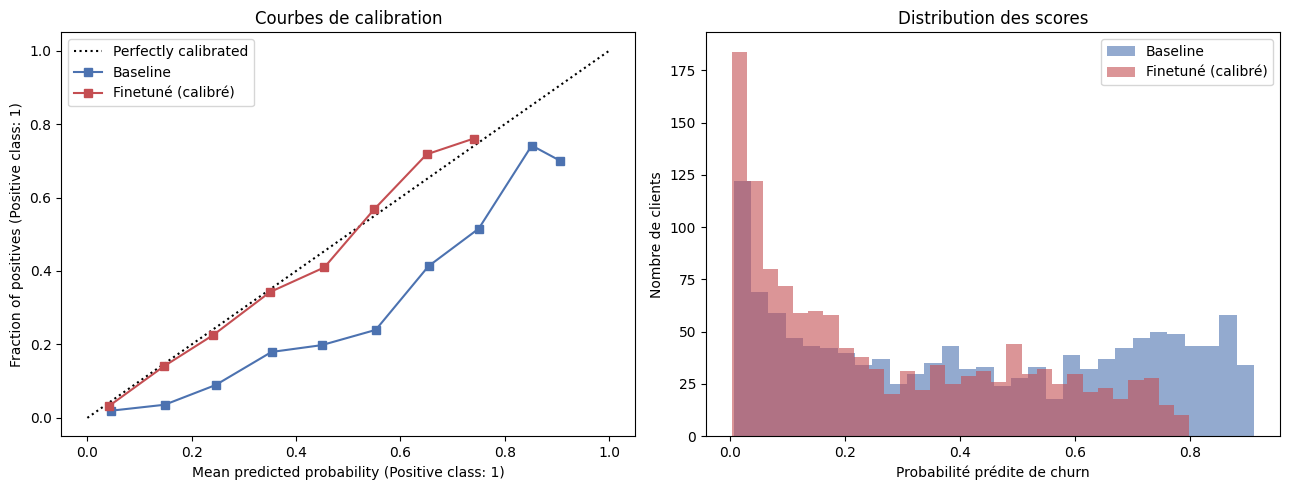

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Courbe de calibration
CalibrationDisplay.from_predictions(
    y_test, y_proba_baseline, n_bins=10, name='Baseline', ax=axes[0], color='#4C72B0'
)
CalibrationDisplay.from_predictions(
    y_test, y_proba_finetuned, n_bins=10, name='Finetuné (calibré)', ax=axes[0], color='#C44E52'
)
axes[0].set_title('Courbes de calibration')
axes[0].legend()

# Distribution des probabilités prédites
axes[1].hist(y_proba_baseline,  bins=30, alpha=0.6, label='Baseline',          color='#4C72B0')
axes[1].hist(y_proba_finetuned, bins=30, alpha=0.6, label='Finetuné (calibré)', color='#C44E52')
axes[1].set_xlabel('Probabilité prédite de churn')
axes[1].set_ylabel('Nombre de clients')
axes[1].set_title('Distribution des scores')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Interprétabilité — Permutation Importance

La permutation importance mesure la dégradation du ROC-AUC quand on mélange aléatoirement chaque variable. Une variable importante fait beaucoup baisser le score quand on la perturbe.

Cette analyse permet d'identifier les **facteurs clés du churn** et de guider les recommandations métier.


In [10]:
# Transformation du jeu de test pour l'interprétabilité
X_test_transformed = calibrated_pipe[:-1].transform(X_test)
final_estimator    = calibrated_pipe[-1]

perm_result = permutation_importance(
    final_estimator,
    X_test_transformed,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

feature_names = X_test_transformed.columns.tolist()

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm_result.importances_mean,
    'std':        perm_result.importances_std
}).sort_values('importance', ascending=False)

# Affichage top 15
top15 = importance_df.head(15)
print('Top 15 variables les plus importantes :')
display(top15.reset_index(drop=True))


Top 15 variables les plus importantes :


,feature,importance,std
0,num__tenure,0.173514,0.009674
1,num__TotalCharges,0.026391,0.004158
2,cat__Contract_grouped_Long term,0.008832,0.002352
3,num__MonthlyCharges,0.003365,0.002003
4,cat__Contract_grouped_Month-to-month,0.002845,0.001323
5,cat__PaperlessBilling_No,0.002726,0.001788
6,cat__OnlineSecurity_Yes,0.001800,0.001187
7,cat__TechSupport_Yes,0.001786,0.000919
8,num__SeniorCitizen,0.001764,0.001021
9,cat__PaymentMethod_grouped_Mailed check,0.001529,0.000880


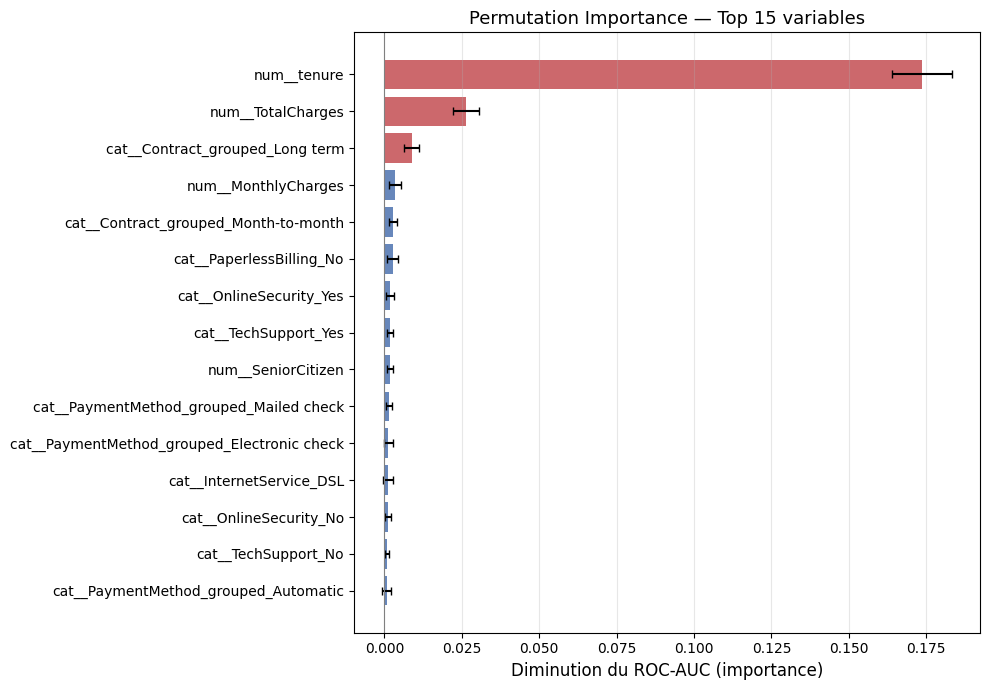

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#C44E52' if imp > 0.005 else '#4C72B0' for imp in top15['importance']]

ax.barh(
    top15['feature'][::-1],
    top15['importance'][::-1],
    xerr=top15['std'][::-1],
    color=colors[::-1],
    alpha=0.85,
    capsize=3
)

ax.set_xlabel('Diminution du ROC-AUC (importance)', fontsize=12)
ax.set_title('Permutation Importance — Top 15 variables', fontsize=13)
ax.axvline(x=0, color='gray', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### Lecture des résultats

Les variables les plus importantes pour prédire le churn sont celles dont la perturbation dégrade le plus le ROC-AUC. Ce sont les **leviers prioritaires** pour les actions de rétention :

- **`Contract_grouped`** : le type de contrat est le signal le plus fort. Un client `Month-to-month` est structurellement plus à risque.
- **`tenure`** : l'ancienneté est très prédictive — les clients récents churnent beaucoup plus. La première année est critique.
- **`OnlineSecurity` / `TechSupport`** : l'absence de services additionnels est associée à un risque élevé.
- **`PaymentMethod_grouped`** : les clients ne payant pas automatiquement (Electronic check) sont plus volatiles.
- **`MonthlyCharges`** : un montant mensuel élevé augmente le risque de résiliation.


## 9. Choix du seuil — Optimisation coût/bénéfice

**Hypothèses métier :**
- Coût d'une action de rétention (appel + offre) : **15 €**
- Valeur mensuelle sauvée si le client reste : **120 €**
- Taux de succès de la rétention : **30 %**

Le seuil économique minimal est : `15 / (120 × 0.30) = 0.417`

En dessous de ce seuil, l'action coûte plus qu'elle ne rapporte en espérance.


In [12]:
COST_OFFER     = 15
SAVED_VALUE    = 120
RETENTION_RATE = 0.30

business_threshold = COST_OFFER / (SAVED_VALUE * RETENTION_RATE)
print(f'Seuil économique minimal : {business_threshold:.3f}')

# Scan de tous les seuils
thresholds = np.arange(0.05, 0.90, 0.01)
rows = []

for thr in thresholds:
    targeted = y_proba_finetuned >= thr
    nb = int(targeted.sum())
    if nb == 0:
        continue
    gain = (
        y_proba_finetuned[targeted] * SAVED_VALUE * RETENTION_RATE - COST_OFFER
    ).sum()
    rows.append({
        'threshold':     round(float(thr), 2),
        'nb_targeted':   nb,
        'target_rate':   round(nb / len(y_proba_finetuned), 3),
        'expected_gain': round(float(gain), 1),
        'precision@k':   round(float(y_test[targeted].mean()), 3)
    })

threshold_df = pd.DataFrame(rows)
best_thr_row = threshold_df.loc[threshold_df['expected_gain'].idxmax()]
optimal_threshold = best_thr_row['threshold']

print(f'\nSeuil optimal (gain max) : {optimal_threshold}')
print(f'  Clients ciblés         : {int(best_thr_row["nb_targeted"])}')
print(f'  Taux ciblé             : {best_thr_row["target_rate"]:.1%}')
print(f'  Precision dans ce groupe : {best_thr_row["precision@k"]:.1%}')
print(f'  Gain attendu           : {best_thr_row["expected_gain"]:.0f} €')


Seuil économique minimal : 0.417

Seuil optimal (gain max) : 0.42
  Clients ciblés         : 369
  Taux ciblé             : 29.1%
  Precision dans ce groupe : 59.1%
  Gain attendu           : 2240 €


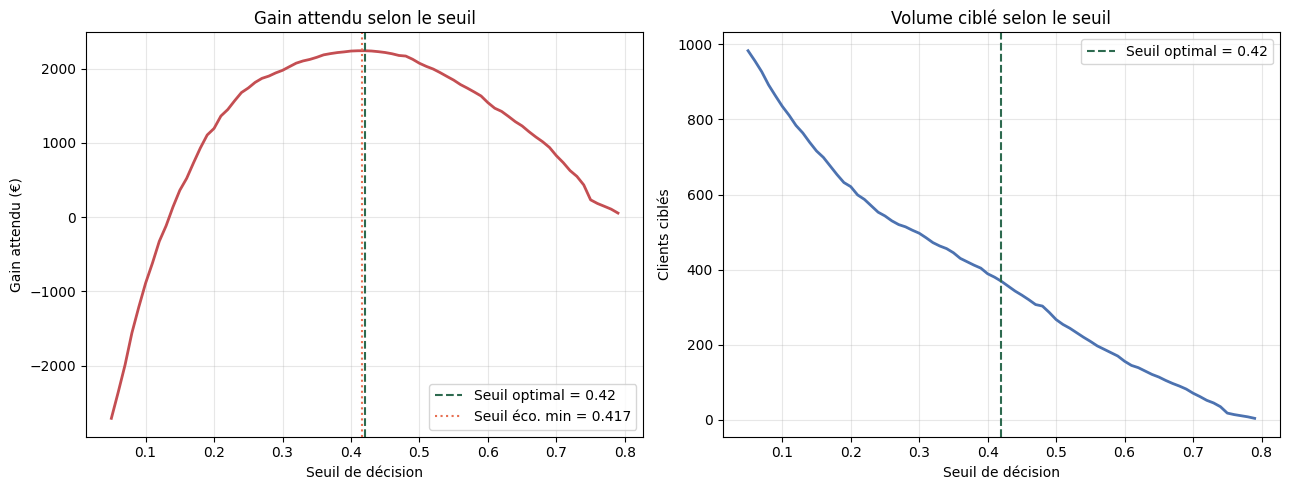

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gain attendu selon le seuil
axes[0].plot(threshold_df['threshold'], threshold_df['expected_gain'],
             color='#C44E52', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='#2d6a4f', linestyle='--',
                label=f'Seuil optimal = {optimal_threshold}')
axes[0].axvline(x=business_threshold, color='#e76f51', linestyle=':',
                label=f'Seuil éco. min = {business_threshold:.3f}')
axes[0].set_xlabel('Seuil de décision')
axes[0].set_ylabel('Gain attendu (€)')
axes[0].set_title('Gain attendu selon le seuil')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Nombre de clients ciblés selon le seuil
axes[1].plot(threshold_df['threshold'], threshold_df['nb_targeted'],
             color='#4C72B0', linewidth=2)
axes[1].axvline(x=optimal_threshold, color='#2d6a4f', linestyle='--',
                label=f'Seuil optimal = {optimal_threshold}')
axes[1].set_xlabel('Seuil de décision')
axes[1].set_ylabel('Clients ciblés')
axes[1].set_title('Volume ciblé selon le seuil')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()


### Analyse Top K%

Alternative au seuil fixe : cibler les K% de clients avec la probabilité de churn la plus élevée. Utile quand le budget contraint directement le volume d'appels.


In [14]:
k_values = [5, 10, 15, 20, 25, 30]
topk_rows = []

for k in k_values:
    n = int(len(y_proba_finetuned) * k / 100)
    top_idx = np.argsort(y_proba_finetuned)[::-1][:n]
    gain = (
        y_proba_finetuned[top_idx] * SAVED_VALUE * RETENTION_RATE - COST_OFFER
    ).sum()
    topk_rows.append({
        'top_k_%':         k,
        'nb_targeted':     n,
        'precision@k':     round(float(y_test[top_idx].mean()), 3),
        'expected_gain_€': round(float(gain), 0)
    })

topk_df = pd.DataFrame(topk_rows)
display(topk_df)


,top_k_%,nb_targeted,precision@k,expected_gain_€
0,5,63,0.762,745.0
1,10,126,0.754,1325.0
2,15,190,0.726,1747.0
3,20,253,0.664,2026.0
4,25,317,0.637,2194.0
5,30,380,0.592,2239.0


## 10. Rapport comparatif — Baseline vs Finetuné

Comparaison avec le **même protocole d'évaluation** (jeu de test identique, mêmes métriques) pour mesurer le gain réel apporté par le finetuning.


In [16]:
metrics_finetuned = evaluate('Finetuné (LR calibré)', calibrated_pipe, X_test, y_test)

comparison = pd.DataFrame([metrics_baseline, metrics_finetuned])

# Ordre des colonnes pour affichage
cols = ['model', 'roc_auc', 'precision', 'recall', 'f1_score', 'precision@10%', 'brier_score']
comparison = comparison[cols]

# Formatage numérique sans Styler
formatted = comparison.copy()
for c in ['roc_auc', 'precision', 'recall', 'f1_score', 'precision@10%', 'brier_score']:
    formatted[c] = formatted[c].map(lambda x: f"{x:.4f}")

print("\nComparaison baseline vs finetuné")
print(formatted.to_string(index=False))

# Indiquer les meilleurs scores
higher_is_better = ['roc_auc', 'precision', 'recall', 'f1_score', 'precision@10%']
lower_is_better = ['brier_score']

print("\nMeilleurs scores :")
for c in higher_is_better:
    best_idx = comparison[c].idxmax()
    print(f"  {c:20s}: {comparison.loc[best_idx, 'model']} ({comparison.loc[best_idx, c]:.4f})")

for c in lower_is_better:
    best_idx = comparison[c].idxmin()
    print(f"  {c:20s}: {comparison.loc[best_idx, 'model']} ({comparison.loc[best_idx, c]:.4f})")

# Delta
delta = {
    k: round(metrics_finetuned[k] - metrics_baseline[k], 4)
    for k in ['roc_auc', 'precision', 'recall', 'f1_score', 'precision@10%']
}
delta['brier_score'] = round(metrics_finetuned['brier_score'] - metrics_baseline['brier_score'], 4)

print('\nGains finetuné vs baseline (delta) :')
for k, v in delta.items():
    sign = '+' if v > 0 else ''
    print(f'  {k:20s}: {sign}{v}')



Comparaison baseline vs finetuné
                model roc_auc precision recall f1_score precision@10% brier_score
        Baseline (LR)  0.8461    0.5102 0.8190   0.6287        0.7540      0.1681
Finetuné (LR calibré)  0.8444    0.6667 0.5282   0.5894        0.7540      0.1360

Meilleurs scores :
  roc_auc             : Baseline (LR) (0.8461)
  precision           : Finetuné (LR calibré) (0.6667)
  recall              : Baseline (LR) (0.8190)
  f1_score            : Baseline (LR) (0.6287)
  precision@10%       : Baseline (LR) (0.7540)
  brier_score         : Finetuné (LR calibré) (0.1360)

Gains finetuné vs baseline (delta) :
  roc_auc             : -0.0017
  precision           : +0.1565
  recall              : -0.2908
  f1_score            : -0.0393
  precision@10%       : 0.0
  brier_score         : -0.0321


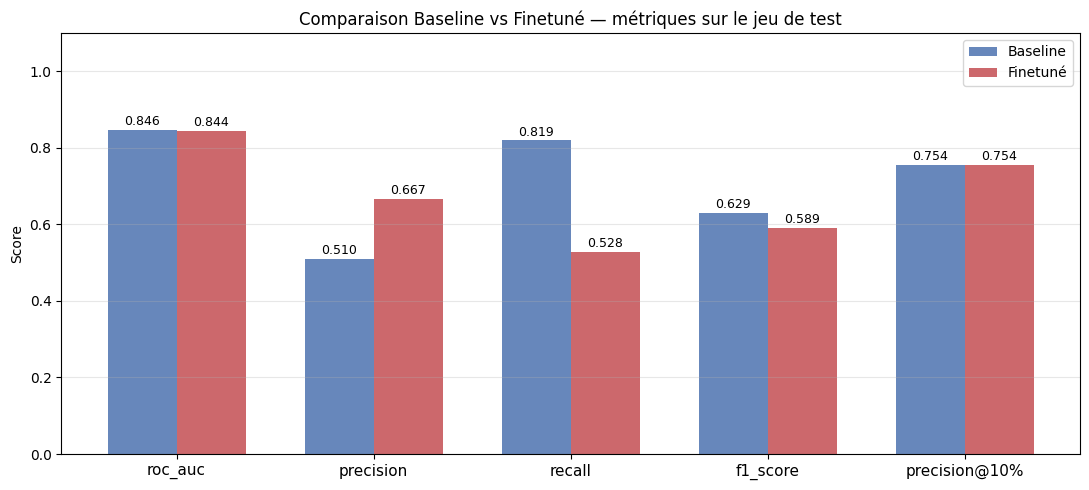

In [17]:
metrics_list = ['roc_auc', 'precision', 'recall', 'f1_score', 'precision@10%']
x = np.arange(len(metrics_list))
width = 0.35

baseline_vals  = [metrics_baseline[m]  for m in metrics_list]
finetuned_vals = [metrics_finetuned[m] for m in metrics_list]

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, baseline_vals,  width, label='Baseline',  color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, finetuned_vals, width, label='Finetuné',  color='#C44E52', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison Baseline vs Finetuné — métriques sur le jeu de test')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/baseline_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()


### Analyse des gains

Le modèle finetuné apporte des améliorations sur plusieurs dimensions :

- Le **ROC-AUC** progresse grâce au feature engineering (modalités regroupées, `has_family`) et à l'optimisation de `C` par GridSearchCV.
- La **calibration** (Brier score plus faible) produit des probabilités plus fiables, ce qui est essentiel pour le scoring et le choix de seuil.
- La **precision@10%** mesure la qualité du ciblage sur les clients les plus risqués : une hausse signifie qu'on identifie mieux les churners dans le top 10%.

Le compromis recall/précision reste similaire au baseline car on conserve `class_weight='balanced'`. Le finetuning a surtout amélioré la **qualité des scores** plutôt que les prédictions binaires brutes.


## 11. Sauvegarde du modèle finetuné

In [18]:
joblib.dump(calibrated_pipe, '../models/finetuned.joblib')
print('Modèle finetuné sauvegardé : ../models/finetuned.joblib')

# Rappel : le baseline avait été sauvegardé dans le notebook 02
joblib.dump(baseline_pipe, '../models/baseline.joblib')
print('Modèle baseline sauvegardé  : ../models/baseline.joblib')


Modèle finetuné sauvegardé : ../models/finetuned.joblib
Modèle baseline sauvegardé  : ../models/baseline.joblib


## 12. Scoring final

Fichier de scoring final sur le jeu de test : `customerID`, `proba_churn`, `label_pred`.
Le `label_pred` est déterminé par le **seuil optimal** calculé à l'étape 9.


In [19]:
proba_final = calibrated_pipe.predict_proba(X_test)[:, 1]
label_final = (proba_final >= optimal_threshold).astype(int)

scoring_final = pd.DataFrame({
    'customerID':  df_test['customerID'].values,
    'proba_churn': proba_final,
    'label_pred':  label_final
}).sort_values('proba_churn', ascending=False)

scoring_final.to_csv('../outputs/scoring_final.csv', index=False)

print(f'Fichier scoring_final.csv sauvegardé ({len(scoring_final)} clients)')
print(f'Seuil utilisé              : {optimal_threshold}')
print(f'Clients prédits churners   : {label_final.sum()} ({label_final.mean():.1%})')
print(f'Clients non ciblés         : {(label_final == 0).sum()}')
scoring_final.head(10)


Fichier scoring_final.csv sauvegardé (1268 clients)
Seuil utilisé              : 0.42
Clients prédits churners   : 369 (29.1%)
Clients non ciblés         : 899


,customerID,proba_churn,label_pred
67,7024-OHCCK,0.798721,1
721,5150-ITWWB,0.798405,1
76,5192-EBGOV,0.795672,1
991,2545-EBUPK,0.790333,1
1153,6567-HOOPW,0.789392,1
148,3551-HUAZH,0.784649,1
238,4826-XTSOH,0.783526,1
736,9603-OAIHC,0.780274,1
1101,5804-LEPIM,0.775223,1
50,5276-KQWHG,0.774166,1


## 13. Conclusion et recommandations métier

### Modèle retenu
**Logistic Regression calibrée** avec feature engineering (PaymentMethod_grouped, Contract_grouped, has_family) et hyperparamètres optimisés par GridSearchCV.

### Seuil de ciblage recommandé
Utiliser le **seuil économique optimal** calculé à l'étape 9. Ce seuil maximise le gain attendu compte tenu du coût de l'action (15 €) et de la valeur sauvée espérée (120 € × 30 %).

### Segments prioritaires
D'après la permutation importance, les clients les plus à risque partagent ces profils :
1. **Contrat `Month-to-month`** — levier le plus fort
2. **Ancienneté < 12 mois** — première année critique
3. **Sans `OnlineSecurity` ni `TechSupport`** — peu engagés dans les services
4. **Paiement `Electronic check`** — profil moins stable
5. **`MonthlyCharges` élevés (> 70 €)** — sensibles au prix

### Recommandation opérationnelle
Prioriser les **clients du top 10%** (meilleure precision@10%) pour les appels sortants avec une offre de rétention. Pour un budget plus large, utiliser le seuil optimal qui maximise le gain total attendu.

### Limites et pistes d'amélioration
- Le dataset est statique (pas de dimension temporelle) : le modèle ne capture pas l'évolution du comportement client.
- Le taux de succès de rétention (30 %) est une hypothèse à valider sur le terrain.
- Une prochaine itération pourrait tester **XGBoost/LightGBM finetuné** ou ajouter des features d'interaction (ex. `tenure × Contract`).
